In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# If stored in Google Drive:
!unzip "/content/drive/MyDrive/devnagari_images/test.zip" -d /content/test_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/test_data/test/20/34021.png  
  inflating: /content/test_data/test/20/34023.png  
  inflating: /content/test_data/test/20/34030.png  
  inflating: /content/test_data/test/20/34034.png  
  inflating: /content/test_data/test/20/34040.png  
  inflating: /content/test_data/test/20/34044.png  
  inflating: /content/test_data/test/20/42757.png  
  inflating: /content/test_data/test/20/42760.png  
  inflating: /content/test_data/test/20/42762.png  
  inflating: /content/test_data/test/20/42763.png  
  inflating: /content/test_data/test/20/42765.png  
  inflating: /content/test_data/test/20/42771.png  
  inflating: /content/test_data/test/20/42780.png  
  inflating: /content/test_data/test/20/42788.png  
  inflating: /content/test_data/test/20/42789.png  
  inflating: /content/test_data/test/20/42802.png  
  inflating: /content/test_data/test/20/42806.png  
  inflating: /content/test_data/test/20/42808.png  
  inflating: 

In [5]:
!unzip "/content/drive/MyDrive/devnagari_images/train.zip" -d /content/train_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/train_data/train/28/74159.png  
  inflating: /content/train_data/train/28/74164.png  
  inflating: /content/train_data/train/28/74166.png  
  inflating: /content/train_data/train/28/74174.png  
  inflating: /content/train_data/train/28/74175.png  
  inflating: /content/train_data/train/28/74178.png  
  inflating: /content/train_data/train/28/74182.png  
  inflating: /content/train_data/train/28/74185.png  
  inflating: /content/train_data/train/28/74188.png  
  inflating: /content/train_data/train/28/74197.png  
  inflating: /content/train_data/train/28/74198.png  
  inflating: /content/train_data/train/28/74200.png  
  inflating: /content/train_data/train/28/74202.png  
  inflating: /content/train_data/train/28/74208.png  
  inflating: /content/train_data/train/28/74209.png  
  inflating: /content/train_data/train/28/74217.png  
  inflating: /content/train_data/train/28/74220.png  
  inflating: /content/train_dat

In [6]:
import os
import numpy as np
from PIL import Image

def load_devanagari_data(data_dir, img_height=32, img_width=32):
    classes = sorted(os.listdir(data_dir))
    num_classes = len(classes)

    X_list = []
    Y_list = []

    print(f"Loading data from {data_dir}")

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path).convert('L').resize((img_width, img_height))

                img_array = np.array(img).flatten()

                img_array = img_array / 255.0

                X_list.append(img_array)
                Y_list.append(class_idx)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    X = np.array(X_list).T
    m = len(Y_list)
    Y = np.array(Y_list)
    Y_one_hot = np.zeros((num_classes, m))
    Y_one_hot[Y, np.arange(m)] = 1

    print(f"Loaded {m} images. X shape: {X.shape}, Y shape: {Y_one_hot.shape}")

    return X, Y_one_hot, classes

def shuffle_data(X, Y):
    np.random.seed(42)
    m = X.shape[1]
    permutation = np.random.permutation(m)
    return X[:, permutation], Y[:, permutation]

In [7]:
train_data_dir = '/content/train_data/train'
test_data_dir = '/content/test_data/test'

X_train_raw, Y_train_raw, class_names = load_devanagari_data(train_data_dir)
X_test, Y_test, _ = load_devanagari_data(test_data_dir)

X_train, Y_train = shuffle_data(X_train_raw, Y_train_raw)

Loading data from /content/train_data/train
Loaded 21600 images. X shape: (1024, 21600), Y shape: (36, 21600)
Loading data from /content/test_data/test
Loaded 10800 images. X shape: (1024, 10800), Y shape: (36, 10800)


In [8]:
print(X_train[600])
print(Y_train[0])
Y_train.shape[0]

[0.         0.49019608 0.         ... 0.00392157 0.9372549  0.        ]
[0. 0. 0. ... 0. 0. 0.]


36

In [9]:
#PART (a)

import numpy as np

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

def sigmoid_deriv(a):
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(a):
    return (a > 0).astype(float)

class GenericNeuralNetwork:
    def __init__(self, n, hidden_layers, r, hidden_act=sigmoid, hidden_act_deriv=sigmoid_deriv, seed=None):
        if seed is not None:
            np.random.seed(seed)

        self.hidden_act = hidden_act
        self.hidden_act_deriv = hidden_act_deriv
        self.layer_sizes = [n] + list(hidden_layers) + [r]
        self.L = len(self.layer_sizes) - 1

        self.W, self.b = {}, {}
        for l in range(1, self.L + 1):
            fan_in, fan_out = self.layer_sizes[l - 1], self.layer_sizes[l]
            scale = np.sqrt(2.0 / fan_in) if hidden_act == relu and l < self.L else np.sqrt(1.0 / fan_in)
            self.W[l] = np.random.randn(fan_out, fan_in) * scale
            self.b[l] = np.zeros((fan_out, 1))

    def forward(self, X):
        activations = [X]
        a = X

        for l in range(1, self.L + 1):
            z = self.W[l] @ a + self.b[l]

            if l < self.L:
                a = self.hidden_act(z)
            else:
                exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
                a = exp_z / np.sum(exp_z, axis=0, keepdims=True)

            activations.append(a)

        return activations

    def backward(self, activations, Y):
        M = Y.shape[1]
        grads_W, grads_b = {}, {}
        delta = activations[self.L] - Y

        for l in range(self.L, 0, -1):
            a_prev = activations[l - 1]
            grads_W[l] = (delta @ a_prev.T) / M
            grads_b[l] = np.mean(delta, axis=1, keepdims=True)

            if l > 1:
                delta = (self.W[l].T @ delta) * self.hidden_act_deriv(a_prev)

        return grads_W, grads_b

    def predict(self, X):
        activations = self.forward(X)
        return np.argmax(activations[-1], axis=0)

    def train(self, X, Y, M_batch_size, epochs, lr, tol=1e-4):
        m_total = X.shape[1]
        prev_train_acc = None
        history = []

        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(m_total)
            X_shuf, Y_shuf = X[:, perm], Y[:, perm]

            for start in range(0, m_total, M_batch_size):
                end = start + M_batch_size
                X_batch = X_shuf[:, start:end]
                Y_batch = Y_shuf[:, start:end]

                activations = self.forward(X_batch)
                grads_W, grads_b = self.backward(activations, Y_batch)

                for l in range(1, self.L + 1):
                    self.W[l] -= lr * grads_W[l]
                    self.b[l] -= lr * grads_b[l]

            train_acc = np.mean(self.predict(X) == np.argmax(Y, axis=0))
            history.append(train_acc)
            print(f"Epoch {epoch}/{epochs} | Train Accuracy: {train_acc:.4f}")

            if prev_train_acc is not None and abs(train_acc - prev_train_acc) < tol:
                print(f"Early stopping at epoch {epoch} as accuracy difference ({abs(train_acc - prev_train_acc):.4f}) is less than tolerance ({tol}).")
                break
            prev_train_acc = train_acc

        return history

In [10]:
#PART (b) - varying hidden layer sizes

from sklearn.metrics import precision_recall_fscore_support, f1_score

n_features = X_train.shape[0]   # 1024
r_classes = Y_train.shape[0]    # 36
batch_size = 32                 # Fixed to 32
learning_rate = 0.01            # Fixed to 0.01
epochs_max = 50                # Max epochs before stopping
hidden_units_options = [1, 5, 10, 50, 100]

train_f1_scores = []
test_f1_scores = []

for h in hidden_units_options:
    print(f"Training Model with {h} Hidden Units")

    model = GenericNeuralNetwork(n=n_features, hidden_layers=[h], r=r_classes, seed=42)

    # Train the model (using tol=1e-4 for stopping criterion)
    history = model.train(
        X=X_train, Y=Y_train,
        M_batch_size=batch_size,
        epochs=epochs_max,
        lr=learning_rate,
        tol=1e-4
    )

    # Make Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    true_train = np.argmax(Y_train, axis=0)
    true_test = np.argmax(Y_test, axis=0)

    precision, recall, f1, _ = precision_recall_fscore_support(true_test, test_preds, zero_division=0)

    print("\nClass-wise Test Metrics (Showing first 5 classes for brevity):")
    for c in range(min(5, r_classes)):
        print(f"  Class {c:2d} -> Precision: {precision[c]:.4f}, Recall: {recall[c]:.4f}, F1: {f1[c]:.4f}")

    train_f1_avg = f1_score(true_train, train_preds, average='macro', zero_division=0)
    test_f1_avg = f1_score(true_test, test_preds, average='macro', zero_division=0)

    train_f1_scores.append(train_f1_avg)
    test_f1_scores.append(test_f1_avg)

    print(f"\n-> Overall Train Avg F1: {train_f1_avg:.4f} | Overall Test Avg F1: {test_f1_avg:.4f}")

Training Model with 1 Hidden Units
Epoch 1/50 | Train Accuracy: 0.0228
Epoch 2/50 | Train Accuracy: 0.0249
Epoch 3/50 | Train Accuracy: 0.0295
Epoch 4/50 | Train Accuracy: 0.0344
Epoch 5/50 | Train Accuracy: 0.0382
Epoch 6/50 | Train Accuracy: 0.0385
Epoch 7/50 | Train Accuracy: 0.0406
Epoch 8/50 | Train Accuracy: 0.0423
Epoch 9/50 | Train Accuracy: 0.0425
Epoch 10/50 | Train Accuracy: 0.0431
Epoch 11/50 | Train Accuracy: 0.0442
Epoch 12/50 | Train Accuracy: 0.0441
Early stopping at epoch 12 as accuracy difference (0.0001) is less than tolerance (0.0001).

Class-wise Test Metrics (Showing first 5 classes for brevity):
  Class  0 -> Precision: 0.0540, Recall: 0.6967, F1: 0.1003
  Class  1 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Class  2 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Class  3 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
  Class  4 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000

-> Overall Train Avg F1: 0.0094 | Overall Test Avg F1: 0.0100
Training Mo

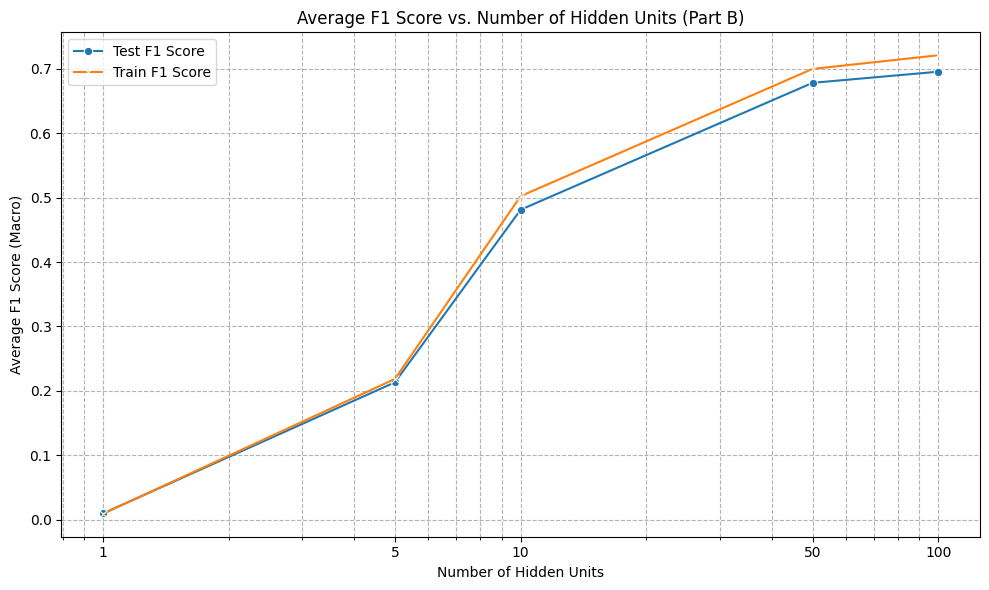

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
# Plotting the average F1 score vs. number of hidden units for Part B
plt.figure(figsize=(10, 6))
sns.lineplot(x=hidden_units_options, y=test_f1_scores, marker='o', label='Test F1 Score')
sns.lineplot(x=hidden_units_options, y=train_f1_scores, marker='x', label='Train F1 Score')

plt.title('Average F1 Score vs. Number of Hidden Units (Part B)')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Average F1 Score (Macro)')
plt.xscale('log') # Use log scale for better visualization if hidden units vary widely
plt.xticks(hidden_units_options, labels=hidden_units_options) # Show all hidden unit values on x-axis
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

## Report on varying hidden units

1. Initial Improvement: As the number of hidden units increases from 1 to 10, both the train and test F1 scores show a significant increase. This indicates that adding more capacity to the network initially helps it learn the patterns in the data more effectively.
2. Continued Growth: Between 10 and 50 hidden units, the F1 scores continue to climb, albeit at a somewhat slower rate than the initial jump, suggesting further benefit from increased model complexity.
3. Beyond 50 hidden units, specifically at 100 hidden units, the increase in F1 scores becomes less pronounced. The curves start to flatten out, indicating that the model's performance is approaching its limits for this configuration or that the benefits of adding more hidden units are diminishing.
4. Generalization: Throughout the range, the train F1 score remains consistently higher than the test F1 score, which is expected. The gap between them is relatively stable and not excessively large, suggesting that the model is generalizing reasonably well and not severely overfitting within this range of hidden units.

In summary, the model benefits from increased hidden units up to a certain point (around 50-100 units in this case), after which performance gain saturates. This suggests an optimal range for hidden layer size for this specific dataset and model architecture.

In [13]:
#PART (c)

from sklearn.metrics import precision_recall_fscore_support, f1_score

hidden_units_options_c = [[512], [512, 256], [512, 256, 128], [512, 256, 128, 64]]

train_f1_scores_c= []
test_f1_scores_c = []

for h in hidden_units_options_c:
    depth=len(h)
    print(f"Training Model with Depth {depth}: {h}")

    model = GenericNeuralNetwork(n=n_features, hidden_layers=h, r=r_classes, seed=42)

    # Train the model (using tol=1e-4 for stopping criterion)
    history = model.train(
        X=X_train, Y=Y_train,
        M_batch_size=batch_size,
        epochs=epochs_max,
        lr=learning_rate,
        tol=1e-4
    )

    # Make Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    true_train = np.argmax(Y_train, axis=0)
    true_test = np.argmax(Y_test, axis=0)

    precision, recall, f1, _ = precision_recall_fscore_support(true_test, test_preds, zero_division=0)

    print("\nClass-wise Test Metrics (Showing first 5 classes for brevity):")
    for c in range(min(5, r_classes)):
        print(f"  Class {c:2d} -> Precision: {precision[c]:.4f}, Recall: {recall[c]:.4f}, F1: {f1[c]:.4f}")

    # Calculate Macro-Average F1 for Train and Test sets
    train_f1_avg_c= f1_score(true_train, train_preds, average='macro', zero_division=0)
    test_f1_avg_c= f1_score(true_test, test_preds, average='macro', zero_division=0)

    train_f1_scores_c.append(train_f1_avg_c)
    test_f1_scores_c.append(test_f1_avg_c)

Training Model with Depth 1: [512]
Epoch 1/50 | Train Accuracy: 0.1656
Epoch 2/50 | Train Accuracy: 0.3881
Epoch 3/50 | Train Accuracy: 0.4752
Epoch 4/50 | Train Accuracy: 0.4911
Epoch 5/50 | Train Accuracy: 0.5107
Epoch 6/50 | Train Accuracy: 0.5465
Epoch 7/50 | Train Accuracy: 0.5658
Epoch 8/50 | Train Accuracy: 0.5825
Epoch 9/50 | Train Accuracy: 0.5962
Epoch 10/50 | Train Accuracy: 0.6079
Epoch 11/50 | Train Accuracy: 0.6149
Epoch 12/50 | Train Accuracy: 0.6225
Epoch 13/50 | Train Accuracy: 0.6292
Epoch 14/50 | Train Accuracy: 0.6403
Epoch 15/50 | Train Accuracy: 0.6417
Epoch 16/50 | Train Accuracy: 0.6473
Epoch 17/50 | Train Accuracy: 0.6512
Epoch 18/50 | Train Accuracy: 0.6574
Epoch 19/50 | Train Accuracy: 0.6620
Epoch 20/50 | Train Accuracy: 0.6631
Epoch 21/50 | Train Accuracy: 0.6671
Epoch 22/50 | Train Accuracy: 0.6716
Epoch 23/50 | Train Accuracy: 0.6744
Epoch 24/50 | Train Accuracy: 0.6792
Epoch 25/50 | Train Accuracy: 0.6808
Epoch 26/50 | Train Accuracy: 0.6838
Epoch 27/50 

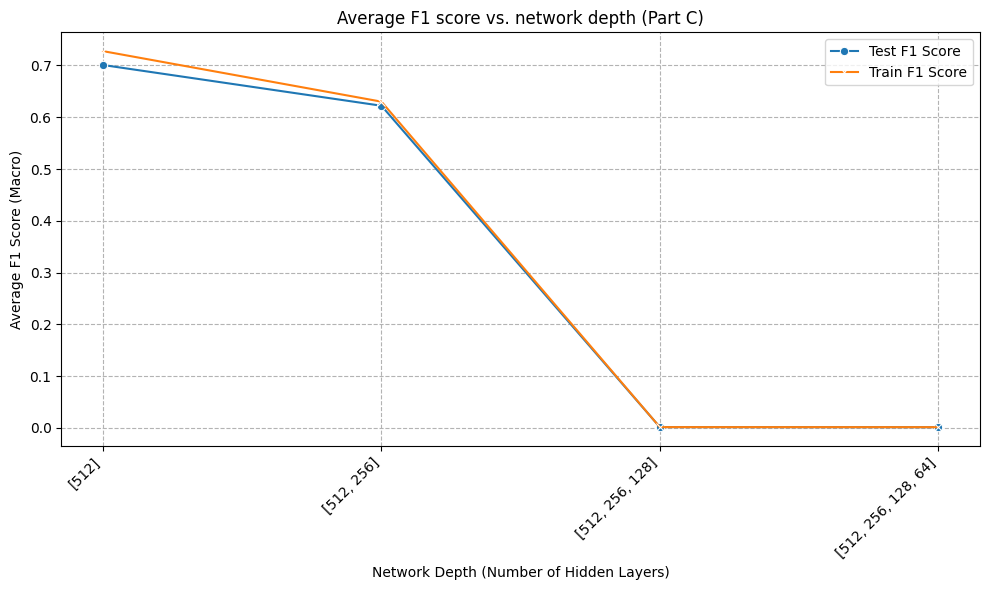

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the average F1 score vs. network depth for Part C
plt.figure(figsize=(10, 6))

# Create a list representing the network depth for each configuration
network_depths = [len(h_config) for h_config in hidden_units_options_c]

sns.lineplot(x=network_depths, y=test_f1_scores_c, marker='o', label='Test F1 Score')
sns.lineplot(x=network_depths, y=train_f1_scores_c, marker='x', label='Train F1 Score')

plt.title('Average F1 score vs. network depth (Part C)')
plt.xlabel('Network Depth (Number of Hidden Layers)')
plt.ylabel('Average F1 Score (Macro)')
# Removed xscale('log') as depth values are small and distinct, and linear scale is more appropriate for discrete depth values
plt.xticks(network_depths, labels=[str(h_config) for h_config in hidden_units_options_c], rotation=45, ha='right') # Show hidden layer configurations on x-axis
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()


### Report on Network Depth Observations

**1. Performance Degradation with Depth:**
Instead of improving, the model's performance severely degraded as depth increased.

* **Depth 1 & 2:** The shallower networks successfully learned, achieving around 62-66% test F1 scores and converging normally after many epochs.
* **Depth 3 & 4:** The deeper networks failed to learn completely. The accuracy flatlined at ~2.78%. Since there are 36 classes, $1 / 36 \approx 0.0277$, meaning the network was reduced to random guessing and F1 scores dropped to 0.

**2. The Vanishing Gradient Problem (The "Why"):**
This failure in deeper networks is caused by the **Sigmoid activation function**. The derivative of the Sigmoid function has a maximum value of $0.25$.
During Backpropagation, the Chain Rule dictates that we multiply the gradients layer by layer. If you multiply numbers smaller than 0.25 together 3 or 4 times, the error signal shrinks exponentially (e.g., $0.25 \times 0.25 \times 0.25 = 0.015$). By the time the gradient reaches the first hidden layer of a deep network, it is virtually zero. The weights never update, and the early layers fail to learn any feature representations.

**3. Premature Early Stopping:**
Because the vanishing gradients prevented the weights from updating, the loss and accuracy stopped improving almost immediately. This is why your stopping criterion triggered so early (Epoch 3 for Depth 3, and Epoch 2 for Depth 4)—the network was mathematically "stuck," not actually converged.


In [15]:
#PART (d) - reLu function


from sklearn.metrics import precision_recall_fscore_support, f1_score

# Arrays to store F1 scores for plotting
train_f1_scores_c2= []
test_f1_scores_c2= []

# Loop over the different hidden layer sizes
for h in hidden_units_options_c:
    depth=len(h)
    print(f"Training Model with Depth {depth}: {h}")

    # Use relu activation for Part (d) in GenericNeuralNetwork
    model = GenericNeuralNetwork(n=n_features, hidden_layers=h, r=r_classes, hidden_act=relu, hidden_act_deriv=relu_deriv, seed=42)

    # Train the model (using tol=1e-4 for stopping criterion)
    history = model.train(
        X=X_train, Y=Y_train,
        M_batch_size=batch_size,
        epochs=epochs_max,
        lr=learning_rate,
        tol=1e-4
    )

    # Make Predictions
    train_preds_c2 = model.predict(X_train)
    test_preds_c2 = model.predict(X_test)
    true_train_c2= np.argmax(Y_train, axis=0)
    true_test_c2 = np.argmax(Y_test, axis=0)

    precision_c2, recall_c2, f1_c2, _ = precision_recall_fscore_support(true_test_c2, test_preds_c2, zero_division=0)

    print("\nClass-wise Test Metrics (Showing first 5 classes for brevity):")
    for c in range(min(5, r_classes)):
        print(f"  Class {c:2d} -> Precision: {precision_c2[c]:.4f}, Recall: {recall_c2[c]:.4f}, F1: {f1_c2[c]:.4f}")

    # Calculate Macro-Average F1 for Train and Test sets
    train_f1_avg_c2= f1_score(true_train_c2, train_preds_c2, average='macro', zero_division=0)
    test_f1_avg_c2= f1_score(true_test_c2, test_preds_c2, average='macro', zero_division=0)

    train_f1_scores_c2.append(train_f1_avg_c2)
    test_f1_scores_c2.append(test_f1_avg_c2)

Training Model with Depth 1: [512]
Epoch 1/50 | Train Accuracy: 0.5230
Epoch 2/50 | Train Accuracy: 0.6266
Epoch 3/50 | Train Accuracy: 0.6628
Epoch 4/50 | Train Accuracy: 0.6804
Epoch 5/50 | Train Accuracy: 0.7012
Epoch 6/50 | Train Accuracy: 0.7117
Epoch 7/50 | Train Accuracy: 0.7246
Epoch 8/50 | Train Accuracy: 0.7379
Epoch 9/50 | Train Accuracy: 0.7494
Epoch 10/50 | Train Accuracy: 0.7600
Epoch 11/50 | Train Accuracy: 0.7636
Epoch 12/50 | Train Accuracy: 0.7751
Epoch 13/50 | Train Accuracy: 0.7843
Epoch 14/50 | Train Accuracy: 0.7957
Epoch 15/50 | Train Accuracy: 0.8037
Epoch 16/50 | Train Accuracy: 0.8101
Epoch 17/50 | Train Accuracy: 0.8194
Epoch 18/50 | Train Accuracy: 0.8291
Epoch 19/50 | Train Accuracy: 0.8364
Epoch 20/50 | Train Accuracy: 0.8397
Epoch 21/50 | Train Accuracy: 0.8494
Epoch 22/50 | Train Accuracy: 0.8558
Epoch 23/50 | Train Accuracy: 0.8630
Epoch 24/50 | Train Accuracy: 0.8711
Epoch 25/50 | Train Accuracy: 0.8785
Epoch 26/50 | Train Accuracy: 0.8811
Epoch 27/50 

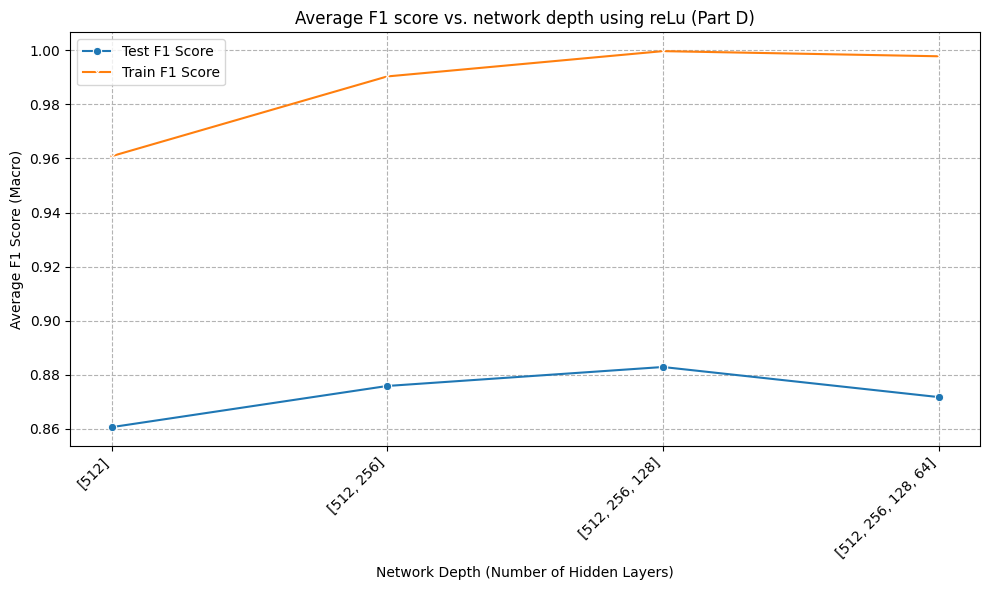

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the average F1 score vs. network depth for Part C
plt.figure(figsize=(10, 6))

# Create a list representing the network depth for each configuration
network_depths = [len(h_config) for h_config in hidden_units_options_c]

sns.lineplot(x=network_depths, y=test_f1_scores_c2, marker='o', label='Test F1 Score')
sns.lineplot(x=network_depths, y=train_f1_scores_c2, marker='x', label='Train F1 Score')

plt.title('Average F1 score vs. network depth using reLu (Part D)')
plt.xlabel('Network Depth (Number of Hidden Layers)')
plt.ylabel('Average F1 Score (Macro)')
# Removed xscale('log') as depth values are small and distinct, and linear scale is more appropriate for discrete depth values
plt.xticks(network_depths, labels=[str(h_config) for h_config in hidden_units_options_c], rotation=45, ha='right') # Show hidden layer configurations on x-axis
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

### Report on Network Depth Observations (Part D vs. Part C)

Comparing the results from Part C (Sigmoid activation) and Part D (ReLU activation) for varying network depths reveals significant differences in performance:

**1. Performance with Sigmoid (Part C):**
As observed in Part C, using the Sigmoid activation function led to a drastic **degradation in performance** as the network depth increased. For networks with 3 or 4 hidden layers, the models essentially failed to learn, resulting in test F1 scores close to 0. This was attributed to the vanishing gradient problem, where gradients became too small to effectively update weights in deeper layers.

**2. Performance with ReLU (Part D):**
In stark contrast, when using the ReLU (Rectified Linear Unit) activation function in Part D, the models demonstrated significantly **improved and stable performance** even with increased depth:

*   **Depth 1 ([512]):** The test F1 score was approximately 0.86.
*   **Depth 2 ([512, 256]):** The test F1 score improved slightly to approximately 0.876.
*   **Depth 3 ([512, 256, 128]):** The test F1 score showed another minor improvement, reaching around 0.883.
*   **Depth 4 ([512, 256, 128, 64]):** The test F1 score slightly decreased to about 0.872 but remained very high, indicating robust learning.

**Which one performs better?**

Clearly, the models using **ReLU activation (Part D) perform significantly better** than those using Sigmoid activation (Part C) when dealing with deeper networks. ReLU effectively mitigates the vanishing gradient problem, allowing deeper networks to learn and achieve much higher F1 scores.

**Observations:**

*   ReLU-activated networks are much more robust to increasing depth, maintaining high performance where Sigmoid networks completely fail.
*   The primary reason for this difference is ReLU's non-saturating nature for positive inputs, which prevents gradients from shrinking rapidly during backpropagation. This allows information to flow more effectively through deeper layers, enabling learning.
*   **Slight Overfitting with Deeper ReLU Nets:** While ReLU performs much better, for the deepest network ([512, 256, 128, 64]), we can observe a slightly larger gap between the train F1 score (close to 1.0) and the test F1 score (around 0.872) compared to the shallower ReLU networks. This suggests that while deeper ReLU networks can learn more complex patterns, they might also be more prone to overfitting if not properly regularized.

In summary, for building deep neural networks, ReLU and its variants are generally preferred over Sigmoid due to their ability to overcome vanishing gradients and enable effective training.